## Path configuration

In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [ ]:
import torch
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from src.data.io import load_pkl
from src.evaluation.eval import encode_latent
from models.deep.MultiVAEPrior import MultiVAE_Bernoulli_SpeciesPrior_Extended

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

## Data loading

In [3]:
ecef = load_pkl("/export/usuarios01/agnavarr/MALDIAlign/experiments/amr/pickles/E-CEF.pkl")
kcef = load_pkl("/export/usuarios01/agnavarr/MALDIAlign/experiments/amr/pickles/K-CEF.pkl")
soxa = load_pkl("/export/usuarios01/agnavarr/MALDIAlign/experiments/amr/pickles/S-OXA.pkl")

In [4]:
ecef_data, ecef_label, ecef_meta, ecef_amr = ecef["data"], ecef["label"], ecef["meta"], ecef["amr"]
kcef_data, kcef_label, kcef_meta, kcef_amr = kcef["data"], kcef["label"], kcef["meta"], kcef["amr"]
soxa_data, soxa_label, soxa_meta, soxa_amr = soxa["data"], soxa["label"], soxa["meta"], soxa["amr"]

In [5]:
PRETRAINED_MODEL_PATH = Path("/export/usuarios01/agnavarr/MALDIAlign/experiments/results/finetuning_vae_multidecoder_prior/20260211_143045/model.pth")

vae_pretrained = MultiVAE_Bernoulli_SpeciesPrior_Extended(
    input_dim=ecef_data.shape[1],
    latent_dim=64,
    num_domains=5,
    n_species=6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae_pretrained.load_state_dict(torch.load(PRETRAINED_MODEL_PATH, map_location=device))
vae_pretrained.to(device)
vae_pretrained.eval()

MultiVAE_Bernoulli_SpeciesPrior_Extended(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=6000, out_features=2048, bias=True)
      (1): ReLU()
      (2): Linear(in_features=2048, out_features=1024, bias=True)
      (3): ReLU()
      (4): Linear(in_features=1024, out_features=512, bias=True)
      (5): ReLU()
    )
    (mu): Linear(in_features=512, out_features=64, bias=True)
    (logvar): Linear(in_features=512, out_features=64, bias=True)
  )
  (decoder): BernoulliDecoder(
    (net): ModuleList(
      (0-4): 5 x Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=1024, bias=True)
        (3): ReLU()
        (4): Linear(in_features=1024, out_features=6000, bias=True)
        (5): Sigmoid()
      )
    )
  )
  (prior): ConditionalPrior(
    (mu_embed): Embedding(6, 64)
    (logvar_embed): Embedding(6, 64)
  )
)

In [6]:
def run_tsne_full(
    X,
    meta,
    amr,
    title,
    random_state=0,
    scale=True
):
    """
    X: numpy array (n_samples, n_features)
    meta: DataFrame with column 'hospital'
    amr: array with AMR labels
    """

    df = meta.copy()
    df["amr"] = amr

    # Remove NaNs in AMR
    valid_mask = pd.notna(df["amr"])
    df = df[valid_mask]
    X = X[valid_mask]

    print(f"[{title}] Using {len(df)} samples.")
    print(df.groupby(["hospital", "amr"]).size())

    # Optional scaling
    if scale:
        X = StandardScaler().fit_transform(X)

    # t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=random_state
    )

    Z = tsne.fit_transform(X)

    df["tsne1"] = Z[:, 0]
    df["tsne2"] = Z[:, 1]

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df,
        x="tsne1",
        y="tsne2",
        hue="amr",
        style="hospital",
        alpha=0.6
    )

    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return Z, df

[E-CEF - ORIGINAL SPACE] Using 8084 samples.
hospital  amr
DRIAMS_A  0.0    3875
          1.0    1086
DRIAMS_B  0.0     168
          1.0      45
DRIAMS_C  0.0     765
          1.0     151
DRIAMS_D  0.0    1796
          1.0     198
dtype: int64


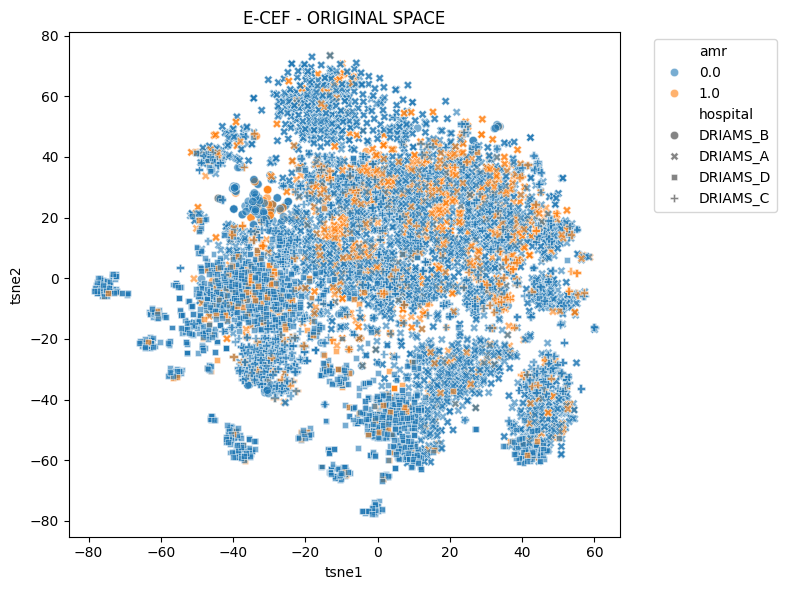

In [7]:
Z_orig, df_orig = run_tsne_full(
    X=ecef_data,
    meta=ecef_meta,
    amr=ecef_amr,
    title="E-CEF - ORIGINAL SPACE"
)

[E-CEF - LATENT SPACE] Using 8084 samples.
hospital  amr
DRIAMS_A  0.0    3875
          1.0    1086
DRIAMS_B  0.0     168
          1.0      45
DRIAMS_C  0.0     765
          1.0     151
DRIAMS_D  0.0    1796
          1.0     198
dtype: int64


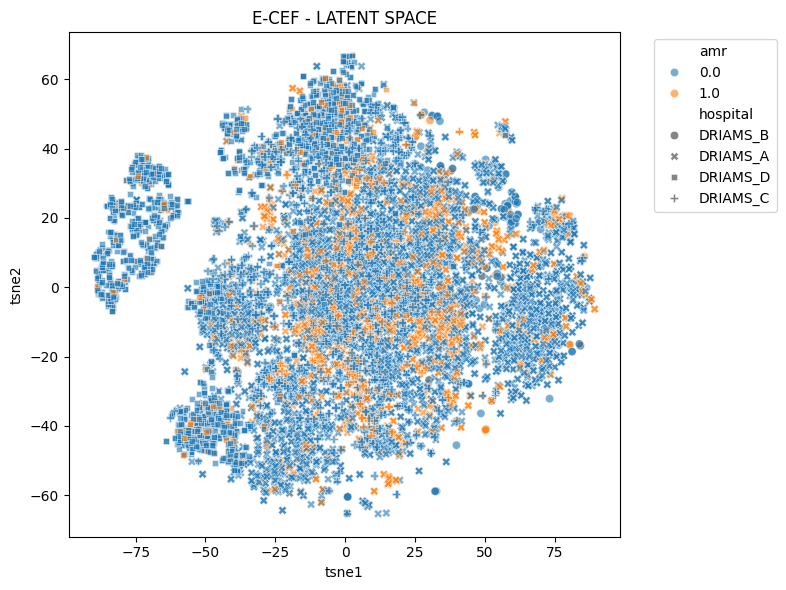

In [8]:
X_latent = encode_latent(vae_pretrained, ecef_data, device)
Z_lat, df_lat = run_tsne_full(
    X=X_latent,
    meta=ecef_meta,
    amr=ecef_amr,
    title="E-CEF - LATENT SPACE"
)